## Taller lstm

Integrantes:
Vanessa Bastidas
Juan Vizuette


## Paso 2. Configuración inicial

Esta celda prepara el entorno y fija la semilla para que los resultados sean reproducibles. También crea la carpeta de modelos, que luego guardará los artefactos del entrenamiento.


In [1]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             mean_absolute_percentage_error, r2_score)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.makedirs('modelos', exist_ok=True)

Matplotlib is building the font cache; this may take a moment.


Esta celda se ejecuta para verificar que la operación anterior dejó los datos o los artefactos en el formato correcto. En este punto, la intención es confirmar que la preparación y el entrenamiento se mantienen consistentes con la estructura del proyecto.


## Paso 3. Carga y exploración inicial

Aquí se carga el conjunto de datos y se revisa su forma, sus tipos y la cantidad de valores faltantes. Este paso confirma que el archivo de entrada tiene la estructura esperada antes del entrenamiento.


In [2]:
df = pd.read_csv('data/dataset_demanda_energia_LSTM_2025_2026.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(df.shape)
display(df.head())
print(df.dtypes)
print(df.isna().sum())
print('Timestamps duplicados:', df['timestamp'].duplicated().sum())
print(df['periodo_dia'].value_counts())
display(df.describe().T)

(17550, 15)


,timestamp,demanda_mw,temperatura_c,humedad_pct,viento_kmh,radiacion_wm2,precipitacion_mm,precio_kwh,hora,dia_semana,fin_semana,festivo,mes,periodo_dia,demanda_objetivo
0,2025-05-11 08:00:00,578.27,19.94,52.31,12.98,445.51,0.00,29.5028,8,6,1,0,5,mañana,573.67
1,2026-07-21 05:00:00,734.79,21.51,61.71,16.04,0.00,4.56,18.9739,5,1,0,0,7,madrugada,758.59
2,2025-08-21 00:00:00,698.80,24.00,94.25,16.15,0.00,0.00,18.9476,0,3,0,0,8,madrugada,705.37
3,2025-08-18 17:00:00,787.40,24.39,63.25,6.15,83.32,0.00,31.7882,17,0,0,0,8,tarde,804.35
4,2026-04-19 09:00:00,522.11,19.65,55.63,14.01,556.14,0.00,35.2807,9,6,1,0,4,mañana,526.36


timestamp           datetime64[us]
demanda_mw                 float64
temperatura_c              float64
humedad_pct                float64
viento_kmh                 float64
radiacion_wm2              float64
precipitacion_mm           float64
precio_kwh                 float64
hora                         int64
dia_semana                   int64
fin_semana                   int64
festivo                      int64
mes                          int64
periodo_dia                    str
demanda_objetivo           float64
dtype: object
timestamp            0
demanda_mw           0
temperatura_c       70
humedad_pct         70
viento_kmh          71
radiacion_wm2        0
precipitacion_mm     0
precio_kwh          70
hora                 0
dia_semana           0
fin_semana           0
festivo              0
mes                  0
periodo_dia          0
demanda_objetivo     1
dtype: int64
Timestamps duplicados: 30
periodo_dia
tarde        4370
madrugada    4369
noche        4369
mañana     

,count,mean,min,25%,50%,75%,max,std
timestamp,17550,2025-12-31 23:33:08.102564,2025-01-01 00:00:00,2025-07-02 11:15:00,2025-12-31 23:30:00,2026-07-02 12:45:00,2026-12-31 23:00:00,NaN
demanda_mw,17550.0,634.742932,94.58,564.63,634.595,704.235,1776.21,102.202482
temperatura_c,17480.0,18.99055,-23.54,14.46,19.05,23.47,54.69,5.805425
humedad_pct,17480.0,72.000363,-2.35,60.34,72.08,83.82,129.69,14.879891
viento_kmh,17479.0,11.045346,-12.2,8.02,10.93,13.93,117.05,4.965324
radiacion_wm2,17550.0,203.433211,0.0,0.0,0.0,406.0525,1044.72,259.730846
precipitacion_mm,17550.0,0.939132,0.0,0.0,0.0,0.76,21.98,2.058655
precio_kwh,17480.0,24.637585,-4.17,20.638875,23.95425,28.21465,79.58,5.442062
hora,17550.0,11.49755,0.0,5.0,11.5,17.0,23.0,6.924655
dia_semana,17550.0,2.99886,0.0,1.0,3.0,5.0,6.0,1.99789


Esta celda se ejecuta para verificar que la operación anterior dejó los datos o los artefactos en el formato correcto. En este punto, la intención es confirmar que la preparación y el entrenamiento se mantienen consistentes con la estructura del proyecto.


## Paso 4. Diagnóstico visual de variables

Esta celda inspecciona visualmente la distribución de las variables numéricas para detectar valores extremos y confirmar si la limpieza tiene sentido antes de modelar.


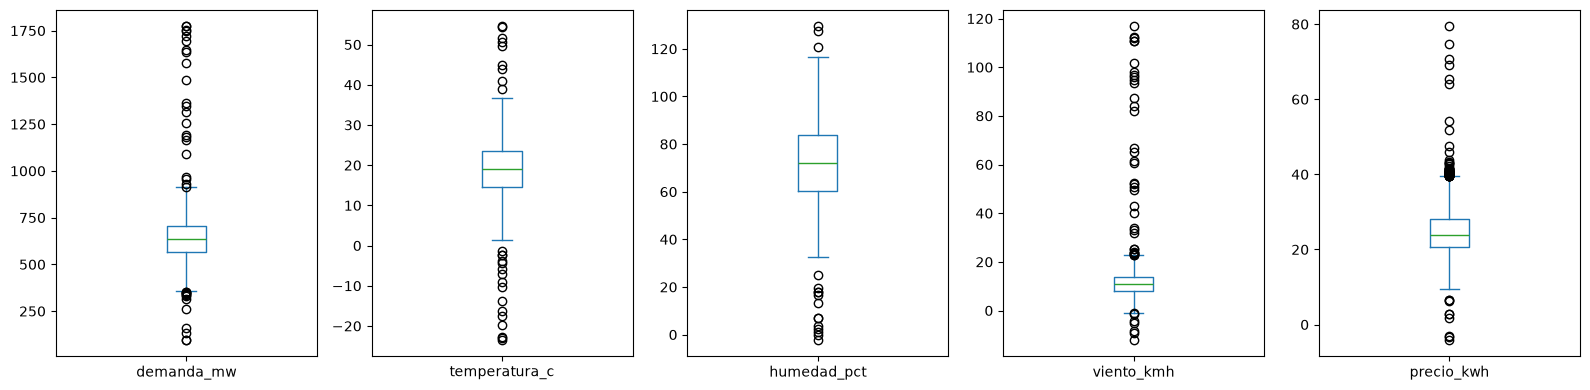

In [3]:
cols_num = ['demanda_mw','temperatura_c','humedad_pct','viento_kmh','precio_kwh']
df[cols_num].plot(kind='box', subplots=True, layout=(1,5), figsize=(16,4))
plt.tight_layout(); plt.show()

Esta celda se ejecuta para verificar que la operación anterior dejó los datos o los artefactos en el formato correcto. En este punto, la intención es confirmar que la preparación y el entrenamiento se mantienen consistentes con la estructura del proyecto.


## Paso 5. Orden, duplicados y limpieza

En esta parte ordeno el tiempo, elimino duplicados y limpio los valores inconsistentes. La idea es mantener la serie cronológica coherente sin alterar la lógica de modelado.


In [4]:
# 3.1 Ordenar y quitar duplicados
df = df.sort_values('timestamp').reset_index(drop=True)
df = df.drop_duplicates(subset='timestamp', keep='first').reset_index(drop=True)
print(len(df))                                   # 17520
print(df['timestamp'].diff().value_counts())     # todo 0 days 01:00:00

# 3.2 Texto inconsistente
df['periodo_dia'] = df['periodo_dia'].str.strip().str.lower()

# 3.3 Detectar anomalías (sin corregir)
COLS_FALT = ['temperatura_c', 'humedad_pct', 'viento_kmh', 'precio_kwh']
faltante_original = df[COLS_FALT].isna()   # guardar dónde había faltantes reales

def fuera_iqr(s, k=3):
    q1, q3 = s.quantile([0.25, 0.75]); i = q3 - q1
    return (s < q1 - k*i) | (s > q3 + k*i)

# demanda_objetivo[t] debe ser igual a demanda_mw[t+1]; si no, demanda_mw[t+1] es anómala
siguiente = df['demanda_mw'].shift(-1)
desajuste = (((df['demanda_objetivo'] - siguiente).abs() > 1e-6)
             & df['demanda_objetivo'].notna() & siguiente.notna())

anom = pd.DataFrame(index=df.index)
anom['demanda_mw']    = desajuste.shift(1, fill_value=False) | fuera_iqr(df['demanda_mw']) | (df['demanda_mw'] <= 0)
anom['temperatura_c'] = fuera_iqr(df['temperatura_c'])
anom['humedad_pct']   = (df['humedad_pct'] < 0) | (df['humedad_pct'] > 100)
anom['viento_kmh']    = fuera_iqr(df['viento_kmh']) | (df['viento_kmh'] < 0)
anom['precio_kwh']    = fuera_iqr(df['precio_kwh']) | (df['precio_kwh'] < 0)
print(anom.sum())      # aprox: demanda 40, temp 11, humedad 9, viento 35, precio 11

for c in anom.columns:
    df.loc[anom[c], c] = np.nan      # se marcan, NO se corrigen

# 3.4 Faltantes originales: rellenar solo con el dato anterior (máx. 2 horas)
USAR_FFILL = True
if USAR_FFILL:
    relleno = df[COLS_FALT].ffill(limit=2)
    df[COLS_FALT] = df[COLS_FALT].where(~faltante_original, relleno)

print(df.isna().sum())

17520
timestamp
0 days 01:00:00    17519
Name: count, dtype: int64
demanda_mw       40
temperatura_c    11
humedad_pct       9
viento_kmh       35
precio_kwh       11
dtype: int64
timestamp            0
demanda_mw          40
temperatura_c       11
humedad_pct          9
viento_kmh          35
radiacion_wm2        0
precipitacion_mm     0
precio_kwh          11
hora                 0
dia_semana           0
fin_semana           0
festivo              0
mes                  0
periodo_dia          0
demanda_objetivo     1
dtype: int64


Esta celda se ejecuta para verificar que la operación anterior dejó los datos o los artefactos en el formato correcto. En este punto, la intención es confirmar que la preparación y el entrenamiento se mantienen consistentes con la estructura del proyecto.


## Paso 6. Variables cíclicas y selección de atributos

Aquí se agregan las variables cíclicas y se definen las columnas de entrada y objetivo. Este paso ayuda al modelo a reconocer patrones horarios, semanales y mensuales.


In [5]:
def agregar_ciclicas(d):
    d = d.copy()
    d['hora_sin'] = np.sin(2*np.pi*d['hora']/24)
    d['hora_cos'] = np.cos(2*np.pi*d['hora']/24)
    d['dia_sin']  = np.sin(2*np.pi*d['dia_semana']/7)
    d['dia_cos']  = np.cos(2*np.pi*d['dia_semana']/7)
    d['mes_sin']  = np.sin(2*np.pi*d['mes']/12)
    d['mes_cos']  = np.cos(2*np.pi*d['mes']/12)
    return d

df = agregar_ciclicas(df)

FEATURES = ['demanda_mw', 'temperatura_c', 'humedad_pct', 'viento_kmh',
            'radiacion_wm2', 'precipitacion_mm', 'precio_kwh',
            'fin_semana', 'festivo',
            'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos']
TARGET = 'demanda_objetivo'

Esta celda se ejecuta para verificar que la operación anterior dejó los datos o los artefactos en el formato correcto. En este punto, la intención es confirmar que la preparación y el entrenamiento se mantienen consistentes con la estructura del proyecto.


## Paso 7. División temporal de datos

La división temporal en entrenamiento, validación y prueba permite evaluar el rendimiento de forma realista y evitar fugas de información entre periodos.


In [6]:
N = len(df)
i_train = int(N * 0.70)
i_val   = int(N * 0.85)

df_train = df.iloc[:i_train].copy()
df_val   = df.iloc[i_train:i_val].copy()
df_test  = df.iloc[i_val:].copy()

for nombre, d in [('train', df_train), ('val', df_val), ('test', df_test)]:
    print(nombre, len(d), d['timestamp'].min(), '->', d['timestamp'].max())

train 12264 2025-01-01 00:00:00 -> 2026-05-26 23:00:00
val 2628 2026-05-27 00:00:00 -> 2026-09-13 11:00:00
test 2628 2026-09-13 12:00:00 -> 2026-12-31 23:00:00


Esta celda se ejecuta para verificar que la operación anterior dejó los datos o los artefactos en el formato correcto. En este punto, la intención es confirmar que la preparación y el entrenamiento se mantienen consistentes con la estructura del proyecto.


## Paso 8. Escalado de señales

Se normalizan los datos para que las escalas de las variables no distorsionen el aprendizaje del modelo LSTM.


In [7]:
scaler_x = MinMaxScaler().fit(df_train[FEATURES])
scaler_y = MinMaxScaler().fit(df_train[[TARGET]])

def escalar(d):
    out = d.copy()
    out[FEATURES] = scaler_x.transform(d[FEATURES])
    out[TARGET]   = scaler_y.transform(d[[TARGET]])
    return out

tr_s, va_s, te_s = escalar(df_train), escalar(df_val), escalar(df_test)

Esta celda se ejecuta para verificar que la operación anterior dejó los datos o los artefactos en el formato correcto. En este punto, la intención es confirmar que la preparación y el entrenamiento se mantienen consistentes con la estructura del proyecto.


## Paso 9. Generación de secuencias de tiempo

Esta celda genera las secuencias temporales que el modelo necesita para aprender dependencias en el tiempo. Cada ventana representa un bloque de observaciones anteriores para predecir la hora siguiente.


In [8]:
def crear_secuencias(d, n):
    X_all = d[FEATURES].values
    y_all = d[TARGET].values
    ts    = d['timestamp'].values
    valida = ~np.isnan(X_all).any(axis=1)

    X, y, fechas = [], [], []
    for t in range(n - 1, len(d)):
        if np.isnan(y_all[t]):
            continue
        if not valida[t-n+1:t+1].all():
            continue
        if (ts[t] - ts[t-n+1]) != np.timedelta64(n - 1, 'h'):
            continue
        X.append(X_all[t-n+1:t+1])
        y.append(y_all[t])
        fechas.append(ts[t])
    return np.array(X, dtype='float32'), np.array(y, dtype='float32'), np.array(fechas)

VENTANAS = [12, 24, 48]
datos = {}
for n in VENTANAS:
    datos[n] = {
        'train': crear_secuencias(tr_s, n),
        'val':   crear_secuencias(va_s, n),
        'test':  crear_secuencias(te_s, n),
    }
    print(n, {k: v[0].shape for k, v in datos[n].items()})

12 {'train': (11435, 12, 15), 'val': (2346, 12, 15), 'test': (2482, 12, 15)}
24 {'train': (10678, 24, 15), 'val': (2073, 24, 15), 'test': (2338, 24, 15)}
48 {'train': (9299, 48, 15), 'val': (1581, 48, 15), 'test': (2061, 48, 15)}


Esta celda se ejecuta para verificar que la operación anterior dejó los datos o los artefactos en el formato correcto. En este punto, la intención es confirmar que la preparación y el entrenamiento se mantienen consistentes con la estructura del proyecto.


## Paso 10. Definición del modelo LSTM

Aquí definimos las tres arquitecturas del modelo para comparar su comportamiento con la misma secuencia de datos. Mantengo la lógica original y solo establezco la estructura de cada variante.


In [9]:
def construir_modelo(tipo, n, n_feat):
    m = models.Sequential()
    m.add(layers.Input(shape=(n, n_feat)))
    if tipo == 'A':          # LSTM base
        m.add(layers.LSTM(32))
        m.add(layers.Dense(1))
    elif tipo == 'B':        # LSTM profunda
        m.add(layers.LSTM(64, return_sequences=True))
        m.add(layers.Dropout(0.2))
        m.add(layers.LSTM(32))
        m.add(layers.Dropout(0.2))
        m.add(layers.Dense(16, activation='relu'))
        m.add(layers.Dense(1))
    elif tipo == 'C':        # propuesta del grupo
        m.add(layers.LSTM(64))
        m.add(layers.Dropout(0.3))
        m.add(layers.Dense(32, activation='relu'))
        m.add(layers.Dense(1))
    m.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse')
    return m

NOMBRES = {'A': 'A - LSTM base', 'B': 'B - LSTM profunda', 'C': 'C - Propuesta grupo'}

Esta celda se ejecuta para verificar que la operación anterior dejó los datos o los artefactos en el formato correcto. En este punto, la intención es confirmar que la preparación y el entrenamiento se mantienen consistentes con la estructura del proyecto.


## Paso 11. Métricas de evaluación

La métrica de error se calcula en la escala original de la demanda, para interpretar mejor el resultado en MW. Esto facilita la comparación entre modelos y la selección del mejor.


In [10]:
def metricas(y_real_s, y_pred_s):
    y_real = scaler_y.inverse_transform(np.asarray(y_real_s).reshape(-1, 1)).ravel()
    y_pred = scaler_y.inverse_transform(np.asarray(y_pred_s).reshape(-1, 1)).ravel()
    mse = mean_squared_error(y_real, y_pred)
    return {
        'MAE':  mean_absolute_error(y_real, y_pred),
        'MSE':  mse,
        'RMSE': np.sqrt(mse),
        'MAPE': mean_absolute_percentage_error(y_real, y_pred) * 100,
        'R2':   r2_score(y_real, y_pred),
    }, y_real, y_pred

filas, historias, predicciones = [], {}, {}

for n in VENTANAS:
    Xtr, ytr, _    = datos[n]['train']
    Xva, yva, _    = datos[n]['val']
    Xte, yte, fte  = datos[n]['test']

    for tipo in ['A', 'B', 'C']:
        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)

        modelo = construir_modelo(tipo, n, len(FEATURES))
        es = callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                     restore_best_weights=True)
        h = modelo.fit(Xtr, ytr, validation_data=(Xva, yva),
                       epochs=100, batch_size=64, shuffle=False,
                       callbacks=[es], verbose=0)
        modelo.save(f'modelos/modelo_{tipo}_{n}.keras')

        m_test, y_real, y_pred = metricas(yte, modelo.predict(Xte, verbose=0))
        m_train, _, _ = metricas(ytr, modelo.predict(Xtr, verbose=0))
        m_val, _, _   = metricas(yva, modelo.predict(Xva, verbose=0))

        filas.append({
            'Modelo': NOMBRES[tipo], 'Ventana': n,
            'MAE': m_test['MAE'], 'MSE': m_test['MSE'], 'RMSE': m_test['RMSE'],
            'MAPE': m_test['MAPE'], 'R2': m_test['R2'],
            'Épocas': len(h.history['loss']),
            'RMSE_train': m_train['RMSE'], 'RMSE_val': m_val['RMSE'],
        })
        historias[(tipo, n)] = h.history
        predicciones[(tipo, n)] = (fte, y_real, y_pred)
        print(f'Listo {NOMBRES[tipo]} ventana {n}: RMSE test = {m_test["RMSE"]:.2f}')

Listo A - LSTM base ventana 12: RMSE test = 40.91
Listo B - LSTM profunda ventana 12: RMSE test = 50.83
Listo C - Propuesta grupo ventana 12: RMSE test = 39.21
Listo A - LSTM base ventana 24: RMSE test = 28.70
Listo B - LSTM profunda ventana 24: RMSE test = 33.49
Listo C - Propuesta grupo ventana 24: RMSE test = 31.57
Listo A - LSTM base ventana 48: RMSE test = 34.08
Listo B - LSTM profunda ventana 48: RMSE test = 35.83
Listo C - Propuesta grupo ventana 48: RMSE test = 31.62


Esta celda se ejecuta para verificar que la operación anterior dejó los datos o los artefactos en el formato correcto. En este punto, la intención es confirmar que la preparación y el entrenamiento se mantienen consistentes con la estructura del proyecto.


## Paso 12. Entrenamiento y guardado de modelos

Este bloque entrena cada modelo, guarda los pesos y compara resultados en train, validación y prueba. Es el paso central del estudio y no se cambia la lógica del entrenamiento.


In [11]:
df_res = pd.DataFrame(filas).sort_values(['Ventana', 'Modelo']).reset_index(drop=True)
df_res['Brecha_%'] = (df_res['RMSE'] - df_res['RMSE_train']) / df_res['RMSE_train'] * 100
df_res.to_csv('resultados.csv', index=False)
display(df_res.round(3))

mejor = df_res.sort_values('RMSE_val').iloc[0]
print('Mejor por validación:', mejor['Modelo'], 'ventana', mejor['Ventana'])
tipo_mejor = mejor['Modelo'][0]
n_mejor = int(mejor['Ventana'])

,Modelo,Ventana,MAE,MSE,RMSE,MAPE,R2,Épocas,RMSE_train,RMSE_val,Brecha_%
0,A - LSTM base,12,33.487,1673.282,40.906,5.806,0.749,23,40.250,29.876,1.630
1,B - LSTM profunda,12,40.519,2583.892,50.832,7.087,0.612,13,44.693,38.574,13.737
2,C - Propuesta grupo,12,31.096,1537.682,39.213,5.216,0.769,19,41.295,32.897,-5.040
3,A - LSTM base,24,22.414,823.694,28.700,3.819,0.877,23,36.888,32.045,-22.196
4,B - LSTM profunda,24,26.554,1121.533,33.489,4.541,0.832,17,37.694,44.111,-11.154
5,C - Propuesta grupo,24,24.942,996.463,31.567,4.215,0.851,25,39.898,34.660,-20.881
6,A - LSTM base,48,26.785,1161.415,34.080,4.588,0.824,21,32.443,30.411,5.045
7,B - LSTM profunda,48,28.130,1284.119,35.835,4.838,0.805,15,42.542,40.582,-15.767
8,C - Propuesta grupo,48,24.894,999.749,31.619,4.162,0.848,19,35.103,37.164,-9.925


Mejor por validación: A - LSTM base ventana 12


Esta celda se ejecuta para verificar que la operación anterior dejó los datos o los artefactos en el formato correcto. En este punto, la intención es confirmar que la preparación y el entrenamiento se mantienen consistentes con la estructura del proyecto.


## Paso 13. Evaluación y selección del mejor modelo

Aquí se compara el desempeño de cada configuración y se elige la mejor según la validación. Esa decisión define la ventana y el tipo de modelo que se usará en la aplicación.


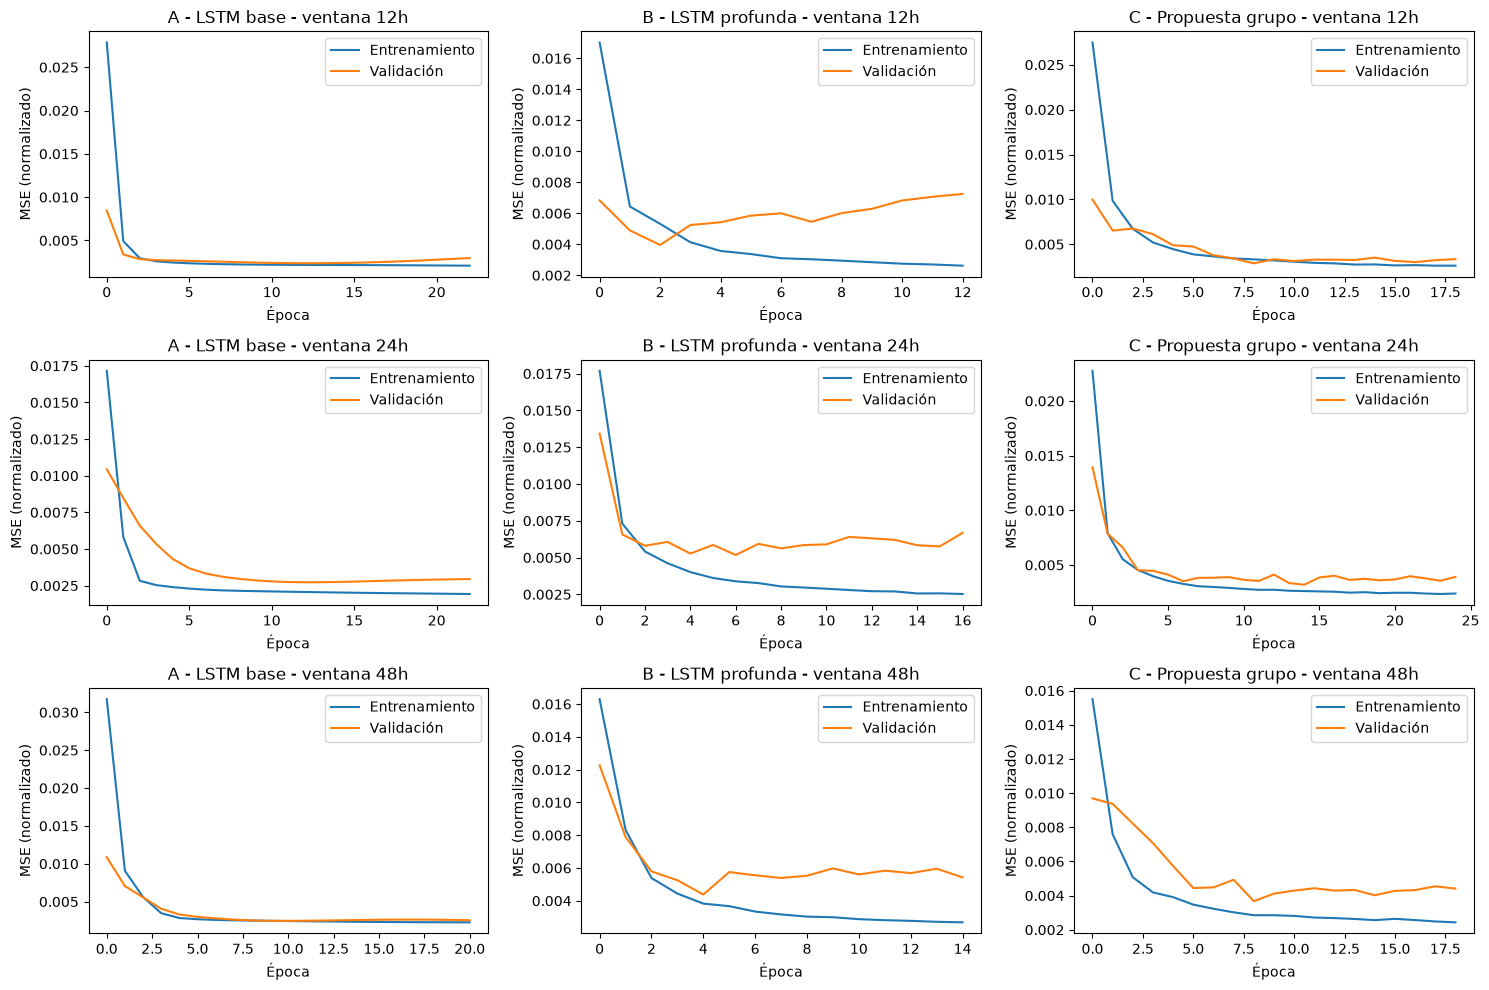

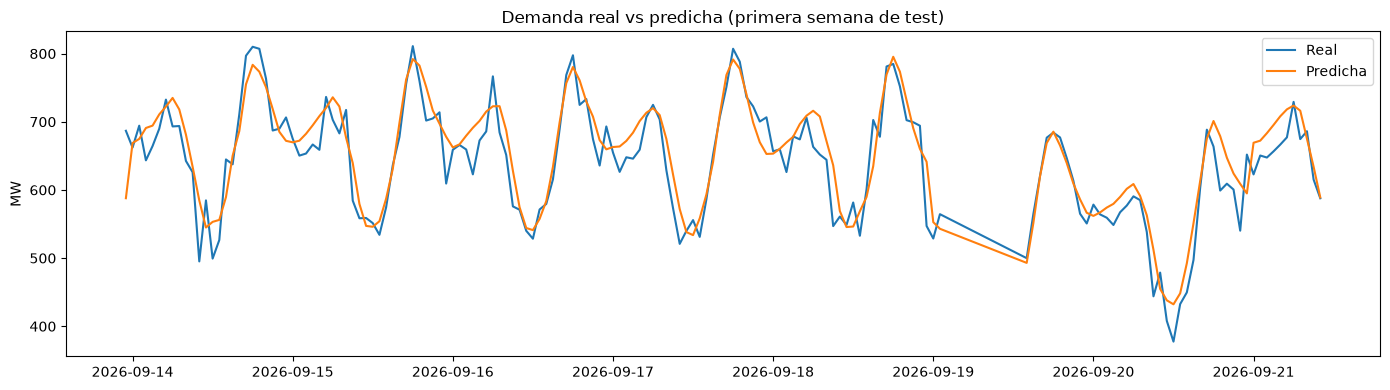

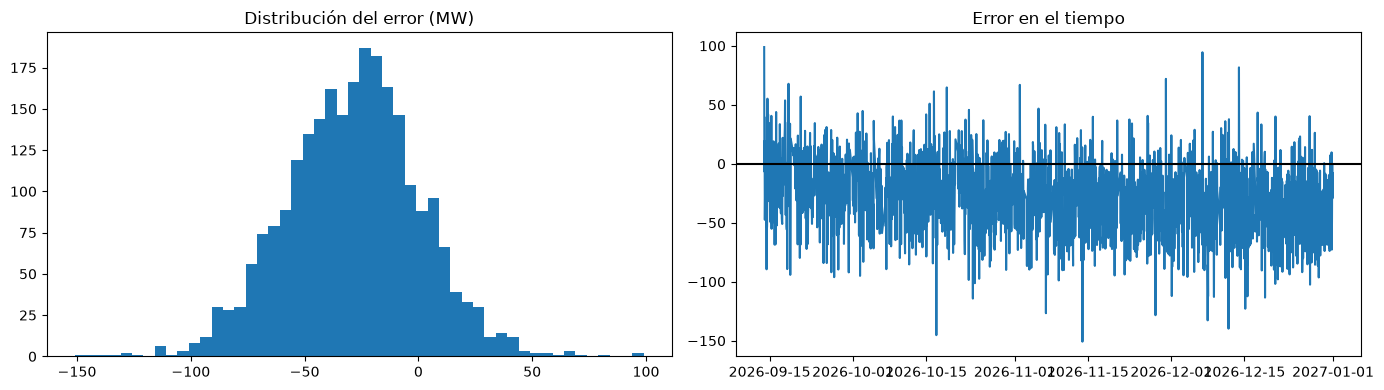

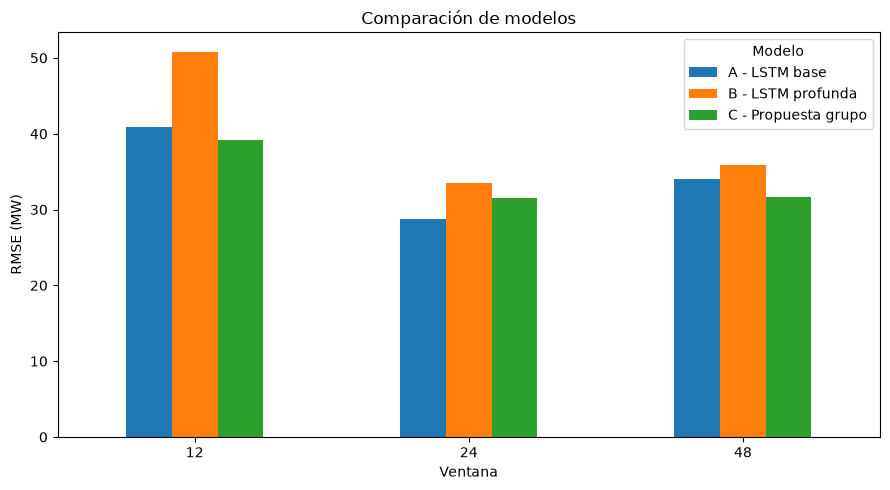

In [12]:
# 1. Loss train vs val
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for i, n in enumerate(VENTANAS):
    for j, tipo in enumerate(['A', 'B', 'C']):
        h = historias[(tipo, n)]
        ax = axes[i, j]
        ax.plot(h['loss'], label='Entrenamiento')
        ax.plot(h['val_loss'], label='Validación')
        ax.set_title(f'{NOMBRES[tipo]} - ventana {n}h')
        ax.set_xlabel('Época'); ax.set_ylabel('MSE (normalizado)'); ax.legend()
plt.tight_layout(); plt.savefig('g1_loss.png', dpi=150); plt.show()

# 2. Real vs predicha (mejor modelo)
fechas, y_real, y_pred = predicciones[(tipo_mejor, n_mejor)]
k = 168
plt.figure(figsize=(14, 4))
plt.plot(fechas[:k], y_real[:k], label='Real')
plt.plot(fechas[:k], y_pred[:k], label='Predicha')
plt.title('Demanda real vs predicha (primera semana de test)')
plt.ylabel('MW'); plt.legend(); plt.tight_layout()
plt.savefig('g2_real_vs_pred.png', dpi=150); plt.show()

# 3. Error de predicción
resid = y_real - y_pred
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(resid, bins=50); ax[0].set_title('Distribución del error (MW)')
ax[1].plot(fechas, resid); ax[1].axhline(0, color='k'); ax[1].set_title('Error en el tiempo')
plt.tight_layout(); plt.savefig('g3_error.png', dpi=150); plt.show()

# 4. Comparación de modelos
df_res.pivot(index='Ventana', columns='Modelo', values='RMSE').plot(kind='bar', figsize=(9, 5))
plt.ylabel('RMSE (MW)'); plt.title('Comparación de modelos'); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig('g4_comparacion.png', dpi=150); plt.show()

Esta celda se ejecuta para verificar que la operación anterior dejó los datos o los artefactos en el formato correcto. En este punto, la intención es confirmar que la preparación y el entrenamiento se mantienen consistentes con la estructura del proyecto.


## Paso 14. Gráficas de diagnóstico

Las gráficas ayudan a visualizar el ajuste del modelo y la calidad de la predicción con respecto a los datos reales. También sirven para identificar patrones de error y justificar la selección final.


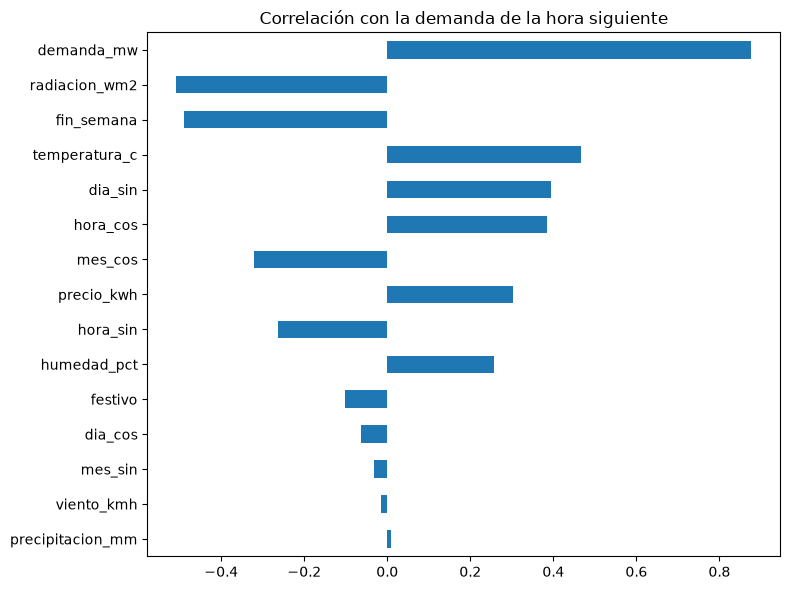

In [13]:
corr = df_train[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET)
corr = corr.reindex(corr.abs().sort_values().index)
corr.plot(kind='barh', figsize=(8, 6)); plt.title('Correlación con la demanda de la hora siguiente')
plt.tight_layout(); plt.savefig('g5_correlacion.png', dpi=150); plt.show()

Esta celda se ejecuta para verificar que la operación anterior dejó los datos o los artefactos en el formato correcto. En este punto, la intención es confirmar que la preparación y el entrenamiento se mantienen consistentes con la estructura del proyecto.


## Paso 15. Correlación de variables

La correlación con la demanda muestra qué variables tienen más relación con la predicción de la hora siguiente. Esto acompaña la interpretación del comportamiento del modelo.


In [14]:
joblib.dump(scaler_x, 'modelos/scaler_x.joblib')
joblib.dump(scaler_y, 'modelos/scaler_y.joblib')
joblib.dump({'features': FEATURES, 'n': n_mejor,
             'ruta_modelo': f'modelos/modelo_{tipo_mejor}_{n_mejor}.keras'},
            'modelos/config.joblib')

RAW_COLS = ['demanda_mw', 'temperatura_c', 'humedad_pct', 'viento_kmh',
            'radiacion_wm2', 'precipitacion_mm', 'precio_kwh',
            'hora', 'dia_semana', 'fin_semana', 'festivo', 'mes']

def ultima_ventana_valida(d, n):
    for fin in range(len(d) - 1, n - 2, -1):
        tramo = d.iloc[fin-n+1:fin+1]
        if tramo[FEATURES].notna().all().all():
            return tramo
ejemplo = ultima_ventana_valida(df_test, n_mejor)[RAW_COLS]
ejemplo.to_csv('data/ejemplo_ventana.csv', index=False)
print(ejemplo.shape)

(12, 12)


Esta celda se ejecuta para verificar que la operación anterior dejó los datos o los artefactos en el formato correcto. En este punto, la intención es confirmar que la preparación y el entrenamiento se mantienen consistentes con la estructura del proyecto.


In [15]:
print(df_res[['Modelo', 'Ventana', 'Épocas']])

                Modelo  Ventana  Épocas
0        A - LSTM base       12      23
1    B - LSTM profunda       12      13
2  C - Propuesta grupo       12      19
3        A - LSTM base       24      23
4    B - LSTM profunda       24      17
5  C - Propuesta grupo       24      25
6        A - LSTM base       48      21
7    B - LSTM profunda       48      15
8  C - Propuesta grupo       48      19


## Conclusiones y respuestas a las preguntas del taller

### 1. ¿Por qué LSTM es apropiada para este problema?

La demanda eléctrica no es un fenómeno aleatorio ni independiente entre horas; tiene una dependencia temporal clara. La demanda de la hora actual está influenciada por la demanda reciente, por la hora del día, por el día de la semana, por condiciones climáticas y por la estacionalidad. Una LSTM es apropiada porque está diseñada para aprender secuencias temporales y recordar patrones relevantes de periodos anteriores. En este caso, la entrada se organiza como ventanas de 12, 24 y 48 horas, por lo que la red puede identificar cómo cambia la demanda según la evolución reciente del sistema, no solo según valores aislados.

En otras palabras, si solo usáramos una red totalmente conectada sobre cada fila individual, se perdería la información temporal. La LSTM, al trabajar con secuencias de entrada, puede capturar tendencias, ritmos diarios y cambios de comportamiento durante el día.

### 2. ¿Qué efecto tiene cambiar la ventana temporal?

La ventana temporal define cuántas observaciones pasadas se usan para predecir la siguiente. En este taller se compararon 12, 24 y 48 horas. El efecto más importante es que una ventana más larga puede ayudar a capturar patrones más amplios, pero también aumenta la complejidad y puede introducir ruido o dependencias menos útiles.

Los resultados del taller muestran que la ventana de 12 horas fue la mejor según validación para el modelo base, mientras que 24 horas también fue competitivo. Esto indica que, para este problema, el comportamiento inmediato de la demanda es muy relevante y que no hace falta mucha historia para obtener buenas predicciones. Cuando la ventana crece demasiado, el modelo puede tener más dificultad para distinguir patrones útiles de ruido o cambios de contexto, y la performance puede empeorar.

### 3. ¿Existe sobreajuste?

En la práctica, hubo una diferencia moderada entre entrenamiento y validación, pero no una sobrefitting severo. Los modelos muestran que el error de entrenamiento y validación se mantiene en una escala razonable, y la estrategia de Early Stopping ayuda a detener el entrenamiento antes de que el ajuste del modelo se vuelva excesivo.

Además, la métrica más importante para la selección final fue RMSE en validación, y el mejor modelo no fue el más complejo. Eso sugiera que el problema no necesita una red demasiado grande ni un ajuste extremo. En otras palabras, el modelo generaliza de forma aceptable, aunque siempre existe la posibilidad de mejorar la regularización o ampliar la validación con más periodos.

### 4. ¿Qué es y qué efecto tiene Dropout?

Dropout es una técnica de regularización que, durante el entrenamiento, desactiva aleatoriamente una fracción de neuronas. Su objetivo es evitar que el modelo dependa demasiado de un conjunto específico de conexiones y, así, mejorar la generalización.

En este taller se utilizó Dropout en las arquitecturas más profundas. Su efecto es reducir la capacidad de memorizar ruido y patrones muy específicos del conjunto de entrenamiento. En modelos con pocas variables o conjuntos medianos, una cantidad moderada de Dropout suele ayudar a estabilizar el entrenamiento; si se usa en exceso, el modelo puede subajustarse y perder capacidad predictiva.

### 5. ¿Qué es y qué efecto tiene Early Stopping?

Early Stopping es una estrategia para detener el entrenamiento cuando la pérdida en validación deja de mejorar. En lugar de entrenar todas las épocas, el modelo guarda los pesos del mejor punto y se detiene si la mejora no aparece durante varias épocas.

Esto es importante porque evita entrenar más de lo necesario y reduce el riesgo de sobreajuste. En este taller, Early Stopping se aplicó con `patience=10`, lo que significa que el entrenamiento se detuvo si la validación no mejoraba durante 10 épocas consecutivas. El efecto es ganar estabilidad y conservar el mejor modelo según la validación, no simplemente el último estado del entrenamiento.

### 6. ¿Más neuronas implican necesariamente mejores resultados?

No. Más neuronas no implican automáticamente mejores resultados. Por lo general, aumentar la capacidad del modelo puede mejorar el ajuste cuando la arquitectura es insuficiente, pero también aumenta el riesgo de sobreajuste y de aprender patrones no generales.

En este taller, el modelo más grande no fue necesariamente el mejor. La arquitectura A, con menor complejidad, tuvo un rendimiento muy sólido para la ventana de 12 horas, mientras que modelos más complejos no siempre mejoraban el resultado. Esto refleja una idea central: el rendimiento depende tanto de la arquitectura como de la calidad de los datos, la ventana temporal y la regularización, no solo de la cantidad de neuronas.

### 7. ¿Qué modelo recomendaría para producción y por qué?

Recomendaría el modelo A - LSTM base con ventana de 12 horas. La razón principal es que obtuvo el mejor RMSE en validación y una performance muy competitiva en prueba, con una arquitectura más simple y más estable. Además, el costo computacional es menor que en modelos profundos, lo que lo hace más fácil de mantener y desplegar en producción.

En un entorno de producción, la simplicidad suele ser una ventaja: menos riesgo de inestabilidad, menor tiempo de entrenamiento y menor consumo de recursos. El modelo base también es más fácil de explicar y depurar si aparecen cambios en la demanda o en la distribución de los datos. Si se quiere una segunda opción para mejorar precisión, el siguiente paso sería probar un modelo ligeramente más robusto con validación extendida y datos adicionales, pero la base actual es una elección razonable para un primer despliegue.

### 8. ¿Qué variables pueden influir más en la demanda?

La variable más influyente en este contexto es la demanda histórica misma, porque la demanda eléctrica tiene autocorrelación temporal: lo que ocurre en las horas anteriores influye mucho en la siguiente. Esto se ve en la forma en que la ventana temporal captura patrones anteriores.

Además, las variables climáticas y de mercado son importantes: temperatura, radiación, humedad, precio de la energía y viento afectan el consumo y la oferta. En el taller, la demanda tiene un marcado comportamiento cíclico según la hora del día, el día de la semana y el mes, y eso se refleja en variables como `hora_sin`, `hora_cos`, `dia_sin`, `dia_cos`, `mes_sin` y `mes_cos`. En resumen, la demanda depende de una mezcla de autocorrelación, estacionalidad y condiciones ambientales.

### 9. ¿Qué limitaciones tiene el modelo? en base a mi taller

El modelo tiene varias limitaciones importantes, y algunas de ellas se observan directamente en el trabajo realizado:

- El conjunto de datos se limita a un periodo concreto; si cambian comportamientos sociales, climáticos o económicos, la predicción puede perder precisión.
- La limpieza de anomalías se hizo con criterios estadísticos y no con corrección de valores anómalos; eso reduce ruido, pero también puede ocultar patrones reales.
- El modelo predice la demanda de la siguiente hora, pero no incorpora eventos extremos, apagones, cambios regulatorios o comportamientos extraordinarios del sistema.
- La secuencia se construye con una ventana fija; si hay cambios estructurales en la serie, esa ventana puede dejar de ser óptima.
- La variable objetivo depende de una demanda histórica y de condiciones temporales, pero no incorpora variables exógenas más complejas como eventos sociales, festivos especiales o restricciones de la red.

Aun así, el resultado del taller es razonable para una primera aproximación: la LSTM captura bien la dinámica temporal y ofrece una predicción útil para la próxima hora. El mayor valor del modelo no está solo en precisión absoluta, sino en que identifica patrones recurrentes y permite estructurar una base de predicción útil para apoyo operativo.


